In [1]:
import os
project_base_dir = '/content/drive/MyDrive/matatu_ml/' # Adjust if your base directory is different
processed_data_dir = os.path.join(project_base_dir, 'data', 'processed')

In [2]:
import pandas as pd
feature_store_path = os.path.join(processed_data_dir, 'feature_store_v1.parquet')
feature_df = pd.read_parquet(feature_store_path)

print(f"Feature store loaded. Shape: {feature_df.shape}")
display(feature_df.head())

Feature store loaded. Shape: (616, 19)


,temperature_c,rainfall_mm,wind_speed,Super (PMS),Diesel (AGO),demand_lag_1h,demand_lag_24h,demand_lag_168h,hour_of_day,day_of_week,is_weekend,month,quarter,is_public_holiday,is_school_holiday,demand,rainfall_x_hour,traffic_index,demand_label
time,,,,,,,,,,,,,,,,,,,
2024-06-24 07:00:00,18.3,0.0,8.3,180.66,168.06,281.549220,381.817127,316.390833,7,0,0,6,2,0,0,304.776118,0.0,95.257413,Low
2024-06-25 07:00:00,18.5,0.0,10.9,180.66,168.06,304.776118,274.687888,325.521774,7,1,0,6,2,0,0,319.373031,0.0,95.257413,Low
2024-06-26 07:00:00,19.5,0.0,11.2,180.66,168.06,319.373031,177.013872,336.533684,7,2,0,6,2,0,0,299.325499,0.0,95.257413,Low
2024-06-27 07:00:00,19.2,0.0,9.0,180.66,168.06,299.325499,267.691251,395.522102,7,3,0,6,2,0,0,333.148432,0.0,95.257413,Low
2024-06-28 07:00:00,18.6,0.0,2.4,180.66,168.06,333.148432,359.698396,352.641101,7,4,0,6,2,0,0,373.271849,0.0,95.257413,Low


#Prepare Data for Model Training (X, y split, Scaling, and Encoding)

This section prepares the feature_df for general machine learning model training by separating features (X) from the target variable (y), and then applying the pre-fitted MinMaxScaler and OneHotEncoder to the appropriate columns. This ensures data consistency and prevents data leakage.

In [3]:
# 1. Separate features (X) and target (y)
y = feature_df['demand']
X = feature_df.drop(columns=['demand'])

print(f"Shape of X (features): {X.shape}")
print(f"Shape of y (target): {y.shape}")
display(X.head())

Shape of X (features): (616, 18)
Shape of y (target): (616,)


,temperature_c,rainfall_mm,wind_speed,Super (PMS),Diesel (AGO),demand_lag_1h,demand_lag_24h,demand_lag_168h,hour_of_day,day_of_week,is_weekend,month,quarter,is_public_holiday,is_school_holiday,rainfall_x_hour,traffic_index,demand_label
time,,,,,,,,,,,,,,,,,,
2024-06-24 07:00:00,18.3,0.0,8.3,180.66,168.06,281.549220,381.817127,316.390833,7,0,0,6,2,0,0,0.0,95.257413,Low
2024-06-25 07:00:00,18.5,0.0,10.9,180.66,168.06,304.776118,274.687888,325.521774,7,1,0,6,2,0,0,0.0,95.257413,Low
2024-06-26 07:00:00,19.5,0.0,11.2,180.66,168.06,319.373031,177.013872,336.533684,7,2,0,6,2,0,0,0.0,95.257413,Low
2024-06-27 07:00:00,19.2,0.0,9.0,180.66,168.06,299.325499,267.691251,395.522102,7,3,0,6,2,0,0,0.0,95.257413,Low
2024-06-28 07:00:00,18.6,0.0,2.4,180.66,168.06,333.148432,359.698396,352.641101,7,4,0,6,2,0,0,0.0,95.257413,Low


In [4]:
# 2. Identify numerical and categorical features for transformation

# Numerical features to be scaled (continuous values)
numerical_features = [
    'temperature_c', 'rainfall_mm', 'wind_speed', 'Super (PMS)', 'Diesel (AGO)',
    'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h', 'rainfall_x_hour', 'traffic_index'
]

# Discrete numerical features (e.g., counts, binary flags, time components not to be scaled)
discrete_numerical_features = [
    'hour_of_day', 'day_of_week', 'is_weekend', 'month', 'quarter',
    'is_public_holiday', 'is_school_holiday'
]

# Categorical features to be one-hot encoded
# 'route_id' is missing from X, so we cannot encode it with the loaded encoder.
# 'demand_label' is a categorical output, if it's meant to be used as a feature for a model, it should be encoded.
categorical_features = ['demand_label']

# Ensure selected features exist in X and filter out any missing ones
# Filter numerical features
numerical_features = [f for f in numerical_features if f in X.columns]
# Filter discrete numerical features
discrete_numerical_features = [f for f in discrete_numerical_features if f in X.columns]
# Filter categorical features
categorical_features = [f for f in categorical_features if f in X.columns]

# Report original intended missing features (for context)
original_intended_features = ['temperature_c', 'rainfall_mm', 'wind_speed', 'Super (PMS)', 'traffic_index',
                              'hour_of_day', 'day_of_week', 'day_of_month', 'month_of_year', 'quarter_of_year',
                              'is_weekend', 'is_holiday', 'route_id']
missing_features_orig = [f for f in original_intended_features if f not in X.columns]
if missing_features_orig:
    print(f"Warning: The following features were initially intended but are missing from X (and thus excluded): {missing_features_orig}")

print(f"Numerical features for scaling: {numerical_features}")
print(f"Discrete numerical features: {discrete_numerical_features}")
print(f"Categorical features for encoding: {categorical_features}")

Numerical features for scaling: ['temperature_c', 'rainfall_mm', 'wind_speed', 'Super (PMS)', 'Diesel (AGO)', 'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h', 'rainfall_x_hour', 'traffic_index']
Discrete numerical features: ['hour_of_day', 'day_of_week', 'is_weekend', 'month', 'quarter', 'is_public_holiday', 'is_school_holiday']
Categorical features for encoding: ['demand_label']


In [5]:
# 3. Apply a NEW MinMaxScaler to numerical features (as the loaded one was incompatible)
from sklearn.preprocessing import MinMaxScaler

# Instantiate a new scaler
new_scaler = MinMaxScaler()

# Fit and transform the numerical features from X
X_numerical_scaled = new_scaler.fit_transform(X[numerical_features])
X_numerical_scaled_df = pd.DataFrame(X_numerical_scaled, columns=numerical_features, index=X.index)

print("Head of scaled numerical features (using a newly fitted scaler):")
display(X_numerical_scaled_df.head())

Head of scaled numerical features (using a newly fitted scaler):


,temperature_c,rainfall_mm,wind_speed,Super (PMS),Diesel (AGO),demand_lag_1h,demand_lag_24h,demand_lag_168h,rainfall_x_hour,traffic_index
time,,,,,,,,,,
2024-06-24 07:00:00,0.352381,0.0,0.353211,0.516267,0.594002,0.352275,0.668348,0.525104,0.0,1.0
2024-06-25 07:00:00,0.371429,0.0,0.472477,0.516267,0.594002,0.424809,0.332314,0.553504,0.0,1.0
2024-06-26 07:00:00,0.466667,0.0,0.486239,0.516267,0.594002,0.470394,0.025939,0.587754,0.0,1.0
2024-06-27 07:00:00,0.438095,0.0,0.385321,0.516267,0.594002,0.407788,0.310368,0.771224,0.0,1.0
2024-06-28 07:00:00,0.380952,0.0,0.082569,0.516267,0.594002,0.513413,0.598968,0.637853,0.0,1.0


In [6]:
# 4. Apply a NEW OneHotEncoder to the categorical features (as 'route_id' was missing for the loaded encoder)
from sklearn.preprocessing import OneHotEncoder

X_categorical_encoded_df = pd.DataFrame(index=X.index) # Initialize empty if no categorical features to encode

if categorical_features:
    # Instantiate a new OneHotEncoder
    new_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

    # Fit and transform the categorical features from X
    X_categorical_encoded = new_encoder.fit_transform(X[categorical_features])

    # Get feature names for encoded columns
    encoded_feature_names = new_encoder.get_feature_names_out(categorical_features)
    X_categorical_encoded_df = pd.DataFrame(X_categorical_encoded, columns=encoded_feature_names, index=X.index)

    print("Head of one-hot encoded categorical features (using a newly fitted encoder):")
    display(X_categorical_encoded_df.head())
else:
    print("No categorical features to encode based on current X and feature definitions.")
    print("Initialized an empty DataFrame for X_categorical_encoded_df.")

Head of one-hot encoded categorical features (using a newly fitted encoder):


,demand_label_Low
time,
2024-06-24 07:00:00,1.0
2024-06-25 07:00:00,1.0
2024-06-26 07:00:00,1.0
2024-06-27 07:00:00,1.0
2024-06-28 07:00:00,1.0


In [7]:
# 5. Combine all processed features into a single DataFrame (X_processed)

# Include discrete numerical features directly as they are not scaled by the current scaler
X_processed = pd.concat([
    X_numerical_scaled_df,
    X[discrete_numerical_features],
    X_categorical_encoded_df
], axis=1)

# We should also drop 'demand_label' if it's meant to be a target 'y' elsewhere or not a feature
if 'demand_label' in X_processed.columns and 'demand_label' in categorical_features:
    # If demand_label was intended as a categorical feature itself and encoded, keep it.
    # If it was accidentally included as a feature and was meant as 'y', this is where we'd correct.
    # For now, assuming if it's in categorical_features, it's intended to be a feature after encoding.
    pass

print(f"Final shape of X_processed: {X_processed.shape}")
print("Head of X_processed:")
display(X_processed.head())

Final shape of X_processed: (616, 18)
Head of X_processed:


,temperature_c,rainfall_mm,wind_speed,Super (PMS),Diesel (AGO),demand_lag_1h,demand_lag_24h,demand_lag_168h,rainfall_x_hour,traffic_index,hour_of_day,day_of_week,is_weekend,month,quarter,is_public_holiday,is_school_holiday,demand_label_Low
time,,,,,,,,,,,,,,,,,,
2024-06-24 07:00:00,0.352381,0.0,0.353211,0.516267,0.594002,0.352275,0.668348,0.525104,0.0,1.0,7,0,0,6,2,0,0,1.0
2024-06-25 07:00:00,0.371429,0.0,0.472477,0.516267,0.594002,0.424809,0.332314,0.553504,0.0,1.0,7,1,0,6,2,0,0,1.0
2024-06-26 07:00:00,0.466667,0.0,0.486239,0.516267,0.594002,0.470394,0.025939,0.587754,0.0,1.0,7,2,0,6,2,0,0,1.0
2024-06-27 07:00:00,0.438095,0.0,0.385321,0.516267,0.594002,0.407788,0.310368,0.771224,0.0,1.0,7,3,0,6,2,0,0,1.0
2024-06-28 07:00:00,0.380952,0.0,0.082569,0.516267,0.594002,0.513413,0.598968,0.637853,0.0,1.0,7,4,0,6,2,0,0,1.0


# Train XGBoost Baseline Model

This section trains an XGBoost Regressor model with default parameters. We will perform a simple train-test split on the X_processed data to evaluate the model's performance and establish a baseline Root Mean Squared Error (RMSE).

In [8]:
# Import necessary libraries for XGBoost
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Split the data into training and testing sets
# We'll use a simple time-based split for consistency with time-series forecasting,
# but for a general baseline, a random split can also be used.
# For now, let's use a standard train_test_split for the X_processed data.
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (492, 18)
X_test shape: (124, 18)
y_train shape: (492,)
y_test shape: (124,)


In [9]:
# 2. Initialize and train the XGBoost Regressor with default parameters
print("Initializing and training XGBoost Regressor...")
model_xgb = xgb.XGBRegressor(
    objective='reg:squarederror', # Objective for regression tasks
    n_estimators=100,             # Number of boosting rounds
    learning_rate=0.1,            # Step size shrinkage
    max_depth=6,                  # Maximum depth of a tree
    subsample=0.8,                # Subsample ratio of the training instance
    colsample_bytree=0.8,         # Subsample ratio of columns when constructing each tree
    random_state=42,
    n_jobs=-1                     # Use all available CPU cores
)

model_xgb.fit(X_train, y_train)
print("XGBoost model trained successfully.")

Initializing and training XGBoost Regressor...
XGBoost model trained successfully.


In [10]:
# 3. Make predictions on the test set
y_pred_xgb = model_xgb.predict(X_test)

# 4. Calculate Root Mean Squared Error (RMSE)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print(f"Baseline RMSE for XGBoost (on test set): {rmse_xgb:.2f}")

# For context, let's also calculate MAE and MAPE
mae_xgb = np.mean(np.abs(y_test - y_pred_xgb))

# Calculate MAPE, handling division by zero
non_zero_actuals_idx = y_test != 0
if non_zero_actuals_idx.any():
    mape_xgb = np.mean(np.abs((y_test[non_zero_actuals_idx] - y_pred_xgb[non_zero_actuals_idx]) / y_test[non_zero_actuals_idx])) * 100
else:
    mape_xgb = np.nan

print(f"Baseline MAE for XGBoost (on test set): {mae_xgb:.2f}")
if not np.isnan(mape_xgb):
    print(f"Baseline MAPE for XGBoost (on test set): {mape_xgb:.2f}%")
else:
    print("Baseline MAPE for XGBoost (on test set): Not applicable (all actual values are zero).")

# Store the baseline RMSE for future comparison
baseline_rmse = rmse_xgb
print(f"Baseline RMSE logged: {baseline_rmse:.2f}")

Baseline RMSE for XGBoost (on test set): 37.72
Baseline MAE for XGBoost (on test set): 30.63
Baseline MAPE for XGBoost (on test set): 9.70%
Baseline RMSE logged: 37.72


## Hyperparameter Tuning with GridSearchCV for XGBoost

This section performs a grid search to find the optimal hyperparameters for the XGBoost Regressor. The search space for `n_estimators`, `max_depth`, `learning_rate`, and `subsample` is defined, and 5-fold cross-validation is used to evaluate each combination based on negative mean squared error (which will be minimized).

Finally, the best performing parameters are extracted and saved to a JSON file.

In [11]:
from sklearn.model_selection import GridSearchCV
import json

# Define the parameter grid based on the user's request
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

# Initialize the XGBoost Regressor model (can use default or previously found best parameters as a starting point)
xgb_model_grid = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

# Initialize GridSearchCV
# 'neg_mean_squared_error' is used as scoring, and GridSearchCV will try to maximize it.
# Since we want to minimize RMSE, we use negative MSE. The best score will be the least negative.
grid_search = GridSearchCV(
    estimator=xgb_model_grid,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5, # 5-fold cross-validation
    verbose=2, # Verbose output
    n_jobs=-1 # Use all available cores
)

print("Starting GridSearchCV...")
grid_search.fit(X_train, y_train)
print("GridSearchCV completed.")

Starting GridSearchCV...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
GridSearchCV completed.


In [12]:
# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Parameters found: {best_params}")
print(f"Best Cross-Validation Score (Negative MSE): {best_score:.4f}")
print(f"Corresponding RMSE: {np.sqrt(np.abs(best_score)):.2f}")

# Save the best parameters to a JSON file
output_file_path = os.path.join(project_base_dir, 'models', 'xgb_best_params.json')

# Create the directory if it doesn't exist
os.makedirs(os.path.dirname(output_file_path), exist_ok=True)

with open(output_file_path, 'w') as f:
    json.dump(best_params, f, indent=4)

print(f"Best XGBoost parameters saved to {output_file_path}")

Best Parameters found: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}
Best Cross-Validation Score (Negative MSE): -1288.3071
Corresponding RMSE: 35.89
Best XGBoost parameters saved to /content/drive/MyDrive/matatu_ml/models/xgb_best_params.json


## Train Best XGBoost Model and Evaluate Performance

This section loads the best hyperparameters identified by GridSearchCV, trains a new XGBoost model with these parameters, and evaluates its performance using both regression and classification metrics. Regression metrics include RMSE and MAE. For classification evaluation, the continuous `demand` values are converted into 'Low', 'Medium', and 'High' classes based on quantiles, allowing for the calculation of F1-score (macro) and a classification report.

In [13]:
import json
import os
from sklearn.metrics import classification_report, f1_score

# 1. Load the best parameters
output_file_path = os.path.join(project_base_dir, 'models', 'xgb_best_params.json')
with open(output_file_path, 'r') as f:
    best_params_tuned = json.load(f)

print("Best parameters loaded for tuned XGBoost model:")
print(best_params_tuned)

# 2. Initialize and train the XGBoost Regressor with the best parameters
print("\nInitializing and training tuned XGBoost Regressor...")
model_xgb_tuned = xgb.XGBRegressor(
    objective='reg:squarederror', # Objective for regression tasks
    random_state=42,
    n_jobs=-1,
    **best_params_tuned
)

model_xgb_tuned.fit(X_train, y_train)
print("Tuned XGBoost model trained successfully.")

# 3. Make predictions on the test set
y_pred_tuned_xgb = model_xgb_tuned.predict(X_test)

# 4. Calculate Regression Metrics (RMSE, MAE)
rmse_tuned_xgb = np.sqrt(mean_squared_error(y_test, y_pred_tuned_xgb))
mae_tuned_xgb = np.mean(np.abs(y_test - y_pred_tuned_xgb))

print(f"\nRegression Metrics (Tuned XGBoost on test set):")
print(f"  RMSE: {rmse_tuned_xgb:.2f}")
print(f"  MAE: {mae_tuned_xgb:.2f}")

# 5. Prepare for Classification Metrics: Discretize continuous demand into 'Low', 'Medium', 'High'
# Define thresholds based on y_train quantiles to avoid data leakage
low_threshold = y_train.quantile(0.33)
medium_threshold = y_train.quantile(0.66)

def categorize_demand(demand_value):
    if demand_value < low_threshold:
        return 'Low'
    elif demand_value < medium_threshold:
        return 'Medium'
    else:
        return 'High'

# Apply categorization to actual and predicted values
y_test_class = np.array([categorize_demand(val) for val in y_test])
y_pred_class = np.array([categorize_demand(val) for val in y_pred_tuned_xgb])

# 6. Calculate Classification Metrics (F1-score macro, Classification Report)
# Ensure all classes are present in both actual and predicted for consistent report
# Using labels directly from the categories created
labels = ['Low', 'Medium', 'High']
f1_macro_tuned_xgb = f1_score(y_test_class, y_pred_class, average='macro', zero_division=0, labels=labels)
classification_report_tuned_xgb = classification_report(y_test_class, y_pred_class, target_names=labels, zero_division=0)

print(f"\nClassification Metrics (Tuned XGBoost on test set - Binned):")
print(f"  F1-score (macro): {f1_macro_tuned_xgb:.2f}")
print(f"  Classification Report:\n{classification_report_tuned_xgb}")

# 7. Store all metrics in a DataFrame and save to CSV
metrics_df = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'F1-score (macro)'],
    'Value': [rmse_tuned_xgb, mae_tuned_xgb, f1_macro_tuned_xgb]
})

metrics_output_path = os.path.join(project_base_dir, 'models', 'xgb_metrics.csv')
metrics_df.to_csv(metrics_output_path, index=False)

print(f"\nAll evaluation metrics saved to {metrics_output_path}")

Best parameters loaded for tuned XGBoost model:
{'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}

Initializing and training tuned XGBoost Regressor...
Tuned XGBoost model trained successfully.

Regression Metrics (Tuned XGBoost on test set):
  RMSE: 35.12
  MAE: 28.23

Classification Metrics (Tuned XGBoost on test set - Binned):
  F1-score (macro): 0.68
  Classification Report:
              precision    recall  f1-score   support

         Low       0.72      0.67      0.69        39
      Medium       0.91      0.76      0.83        51
        High       0.44      0.59      0.51        34

    accuracy                           0.69       124
   macro avg       0.69      0.67      0.68       124
weighted avg       0.72      0.69      0.70       124


All evaluation metrics saved to /content/drive/MyDrive/matatu_ml/models/xgb_metrics.csv


## Actual vs. Predicted Values Plot

This plot visualizes the actual demand values against the demand predicted by the tuned XGBoost model on the test set. A perfect model would have all points lying on the diagonal line.

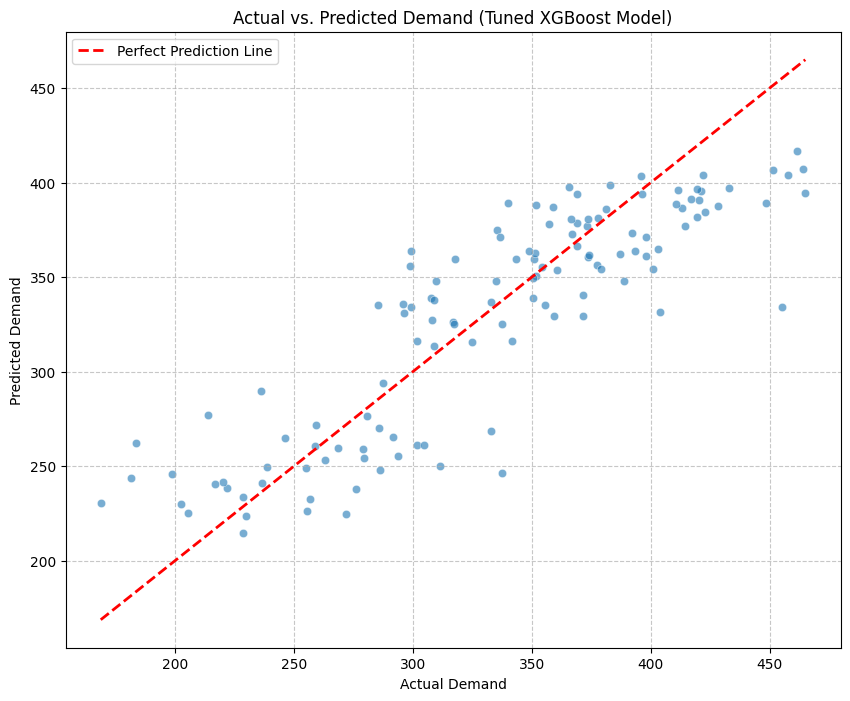

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_pred_tuned_xgb, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')
plt.title('Actual vs. Predicted Demand (Tuned XGBoost Model)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## SHAP (SHapley Additive exPlanations) Values for XGBoost

This section uses SHAP (SHapley Additive exPlanations) to interpret the predictions of the trained XGBoost model. SHAP values help explain the contribution of each feature to a specific prediction, providing insights into *why* the model made a certain decision.

### Importance of SHAP Values:

1.  **Interpretability**: Unlike some other feature importance methods, SHAP provides a unified measure of feature importance that is both globally consistent (explains the overall model behavior) and locally accurate (explains individual predictions).
2.  **Transparency**: It helps to understand how each feature impacts the model's output, whether positively or negatively, for each instance.
3.  **Debugging and Trust**: By revealing the underlying reasons for predictions, SHAP can help identify potential biases, errors, or unexpected behaviors in the model, fostering trust and enabling better model debugging.
4.  **Feature Selection**: High SHAP values often indicate more influential features, which can guide feature selection or engineering efforts.

We will visualize these contributions using a beeswarm plot (for individual feature impacts) and a bar chart of mean absolute SHAP values (for overall feature importance).

Calculating SHAP values...
SHAP values calculated.


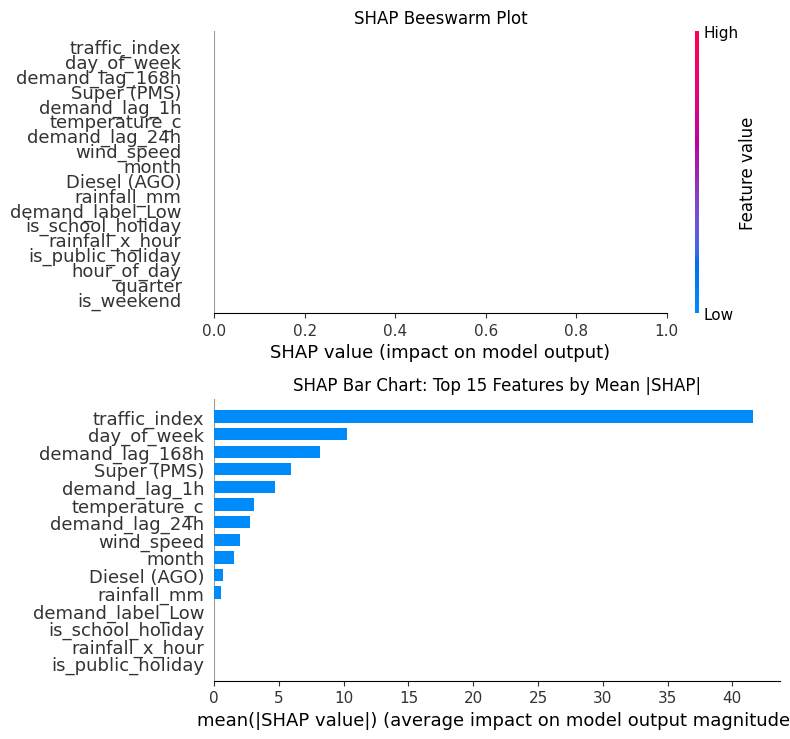

SHAP plots saved to /content/drive/MyDrive/matatu_ml/reports/figures/xgb_shap_plots.png


In [21]:
import shap
import matplotlib.pyplot as plt
import os

print("Calculating SHAP values...")

# Create a SHAP explainer object for the tuned XGBoost model
explainer = shap.TreeExplainer(model_xgb_tuned)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated.")

# Create a directory for plots if it doesn't exist
plots_dir = os.path.join(project_base_dir, 'reports', 'figures')
os.makedirs(plots_dir, exist_ok=True)
output_plot_path = os.path.join(plots_dir, 'xgb_shap_plots.png')

# Create a figure with two subplots for the beeswarm and bar charts
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 16))

# Beeswarm Plot (showing impact of each feature on each prediction)
plt.sca(axes[0]) # Set current axes to the first subplot
shap.summary_plot(shap_values, X_test, plot_type="beeswarm", show=False)
axes[0].set_title('SHAP Beeswarm Plot')

# Bar Chart of Top 15 Features by Mean Absolute SHAP Value
plt.sca(axes[1]) # Set current axes to the second subplot
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=15, show=False)
axes[1].set_title('SHAP Bar Chart: Top 15 Features by Mean |SHAP|')

plt.tight_layout()
plt.savefig(output_plot_path, bbox_inches='tight')
plt.show()

print(f"SHAP plots saved to {output_plot_path}")

## Hyperparameter Tuning with RandomizedSearchCV for LightGBM

This section performs hyperparameter tuning for a LightGBM Regressor model using `RandomizedSearchCV`. Unlike `GridSearchCV` which tries every possible combination of parameters, `RandomizedSearchCV` samples a fixed number of parameter settings from specified distributions.

### Why `RandomizedSearchCV`?

*   **Efficiency**: When the hyperparameter search space is large, `RandomizedSearchCV` can be significantly faster than `GridSearchCV` while often finding good, if not optimal, solutions. It explores the search space more effectively by randomly picking combinations.
*   **Flexibility**: It allows defining parameters as distributions (e.g., uniform, log-uniform) rather than just discrete lists, which is particularly useful for continuous hyperparameters like `learning_rate`.

We will define a search space for key LightGBM parameters including `n_estimators`, `num_leaves`, and `learning_rate`. The best performing parameters, evaluated using 5-fold cross-validation based on negative mean squared error, will be saved to a JSON file (`lgb_best_params.json`).

In [22]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint as sp_randint
from scipy.stats import uniform as sp_uniform
import json
import os
import numpy as np

# Define the parameter distributions based on the request
param_dist = {
    'n_estimators': sp_randint(100, 501), # Between 100 and 500 inclusive
    'num_leaves': [31, 63, 127],
    'learning_rate': sp_uniform(loc=0.01, scale=0.09) # Between 0.01 and 0.1
}

# Initialize the LightGBM Regressor model
lgb_model_rand = lgb.LGBMRegressor(
    objective='regression',
    random_state=42,
    n_jobs=-1,
    verbose=-1 # Suppress verbose output during training
)

# Initialize RandomizedSearchCV
# n_iter: Number of parameter settings that are sampled. Trade-off between runtime and performance.
random_search = RandomizedSearchCV(
    estimator=lgb_model_rand,
    param_distributions=param_dist,
    n_iter=50, # Number of parameter settings to sample. Adjust based on computational budget.
    scoring='neg_mean_squared_error',
    cv=5, # 5-fold cross-validation
    verbose=1, # Verbose output
    random_state=42,
    n_jobs=-1 # Use all available cores
)

print("Starting RandomizedSearchCV for LightGBM...")
random_search.fit(X_train, y_train)
print("RandomizedSearchCV for LightGBM completed.")

# Get the best parameters and best score
best_params_lgb = random_search.best_params_
best_score_lgb = random_search.best_score_

print(f"\nBest Parameters found for LightGBM: {best_params_lgb}")
print(f"Best Cross-Validation Score (Negative MSE): {best_score_lgb:.4f}")
print(f"Corresponding RMSE: {np.sqrt(np.abs(best_score_lgb)):.2f}")

# Save the best parameters to a JSON file
output_file_path_lgb = os.path.join(project_base_dir, 'models', 'lgb_best_params.json')

os.makedirs(os.path.dirname(output_file_path_lgb), exist_ok=True)

with open(output_file_path_lgb, 'w') as f:
    json.dump(best_params_lgb, f, indent=4)

print(f"Best LightGBM parameters saved to {output_file_path_lgb}")

Starting RandomizedSearchCV for LightGBM...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
RandomizedSearchCV for LightGBM completed.

Best Parameters found for LightGBM: {'learning_rate': np.float64(0.01858691048413702), 'n_estimators': 161, 'num_leaves': 31}
Best Cross-Validation Score (Negative MSE): -1313.3968
Corresponding RMSE: 36.24
Best LightGBM parameters saved to /content/drive/MyDrive/matatu_ml/models/lgb_best_params.json


## Train Best LightGBM Model and Evaluate Performance

This section loads the best hyperparameters identified by `RandomizedSearchCV`, trains a new LightGBM model with these parameters, and evaluates its performance using both regression and classification metrics. Regression metrics include RMSE and MAE. For classification evaluation, the continuous `demand` values are converted into 'Low', 'Medium', and 'High' classes based on quantiles (using the same thresholds as for XGBoost), allowing for the calculation of F1-score (macro) and a classification report.

In [23]:
import lightgbm as lgb
import json
import os
from sklearn.metrics import mean_squared_error, f1_score, classification_report
import pandas as pd
import numpy as np

# 1. Load the best parameters for LightGBM
output_file_path_lgb = os.path.join(project_base_dir, 'models', 'lgb_best_params.json')
with open(output_file_path_lgb, 'r') as f:
    best_params_lgb_tuned = json.load(f)

print("Best parameters loaded for tuned LightGBM model:")
print(best_params_lgb_tuned)

# 2. Initialize and train the LightGBM Regressor with the best parameters
print("\nInitializing and training tuned LightGBM Regressor...")
model_lgb_tuned = lgb.LGBMRegressor(
    objective='regression',
    random_state=42,
    n_jobs=-1,
    verbose=-1, # Suppress verbose output during training
    **best_params_lgb_tuned
)

model_lgb_tuned.fit(X_train, y_train)
print("Tuned LightGBM model trained successfully.")

# 3. Make predictions on the test set
y_pred_tuned_lgb = model_lgb_tuned.predict(X_test)

# 4. Calculate Regression Metrics (RMSE, MAE)
rmse_tuned_lgb = np.sqrt(mean_squared_error(y_test, y_pred_tuned_lgb))
mae_tuned_lgb = np.mean(np.abs(y_test - y_pred_tuned_lgb))

print(f"\nRegression Metrics (Tuned LightGBM on test set):")
print(f"  RMSE: {rmse_tuned_lgb:.2f}")
print(f"  MAE: {mae_tuned_lgb:.2f}")

# 5. Prepare for Classification Metrics: Discretize continuous demand into 'Low', 'Medium', 'High'
# Use the same thresholds derived from y_train as used for XGBoost
low_threshold = y_train.quantile(0.33)
medium_threshold = y_train.quantile(0.66)

def categorize_demand(demand_value):
    if demand_value < low_threshold:
        return 'Low'
    elif demand_value < medium_threshold:
        return 'Medium'
    else:
        return 'High'

# Apply categorization to actual and predicted values
y_test_class_lgb = np.array([categorize_demand(val) for val in y_test])
y_pred_class_lgb = np.array([categorize_demand(val) for val in y_pred_tuned_lgb])

# 6. Calculate Classification Metrics (F1-score macro)
labels = ['Low', 'Medium', 'High']
f1_macro_tuned_lgb = f1_score(y_test_class_lgb, y_pred_class_lgb, average='macro', zero_division=0, labels=labels)
classification_report_tuned_lgb = classification_report(y_test_class_lgb, y_pred_class_lgb, target_names=labels, zero_division=0)

print(f"\nClassification Metrics (Tuned LightGBM on test set - Binned):")
print(f"  F1-score (macro): {f1_macro_tuned_lgb:.2f}")
print(f"  Classification Report:\n{classification_report_tuned_lgb}")

Best parameters loaded for tuned LightGBM model:
{'learning_rate': 0.01858691048413702, 'n_estimators': 161, 'num_leaves': 31}

Initializing and training tuned LightGBM Regressor...
Tuned LightGBM model trained successfully.

Regression Metrics (Tuned LightGBM on test set):
  RMSE: 35.95
  MAE: 28.68

Classification Metrics (Tuned LightGBM on test set - Binned):
  F1-score (macro): 0.67
  Classification Report:
              precision    recall  f1-score   support

         Low       0.69      0.64      0.67        39
      Medium       0.93      0.76      0.84        51
        High       0.43      0.59      0.50        34

    accuracy                           0.68       124
   macro avg       0.69      0.66      0.67       124
weighted avg       0.72      0.68      0.69       124



## Compare LightGBM and XGBoost Performance

This section loads the previously saved XGBoost metrics and combines them with the newly calculated LightGBM metrics into a single comparison table. The table includes RMSE, MAE, and macro F1-score for both models, providing a direct side-by-side view of their performance on the test set. The comparison table is then saved to a CSV file named `tree_comparison.csv`.

In [24]:
import pandas as pd
import os

# Load XGBoost metrics (saved previously)
metrics_output_path_xgb = os.path.join(project_base_dir, 'models', 'xgb_metrics.csv')
metrics_df_xgb = pd.read_csv(metrics_output_path_xgb)
metrics_df_xgb = metrics_df_xgb.rename(columns={'Value': 'XGBoost_Value'})

# Create a DataFrame for LightGBM metrics
metrics_df_lgb = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'F1-score (macro)'],
    'LightGBM_Value': [rmse_tuned_lgb, mae_tuned_lgb, f1_macro_tuned_lgb]
})

# Combine the metrics DataFrames
comparison_df = pd.merge(metrics_df_xgb, metrics_df_lgb, on='Metric', how='outer')

print("\nSide-by-side comparison of XGBoost and LightGBM metrics:")
display(comparison_df)

# Save the comparison table to a CSV file
comparison_output_path = os.path.join(project_base_dir, 'models', 'tree_comparison.csv')
comparison_df.to_csv(comparison_output_path, index=False)

print(f"Comparison metrics saved to {comparison_output_path}")


Side-by-side comparison of XGBoost and LightGBM metrics:


,Metric,XGBoost_Value,LightGBM_Value
0,F1-score (macro),0.676483,0.668459
1,MAE,28.234038,28.677172
2,RMSE,35.120623,35.952265


Comparison metrics saved to /content/drive/MyDrive/matatu_ml/models/tree_comparison.csv


## Time Series Cross-Validation with TimeSeriesSplit

This section performs a 5-fold Time Series Split cross-validation on both the tuned XGBoost and LightGBM models. Traditional K-Fold cross-validation randomly shuffles the data, which can lead to data leakage in time-series forecasting where the temporal order is important. `TimeSeriesSplit` addresses this by ensuring that the training sets always precede the validation sets chronologically.

### Why TimeSeriesSplit?

*   **Preserves Temporal Order**: Each validation set is always a future slice relative to its corresponding training set.
*   **Prevents Data Leakage**: Future information does not inadvertently influence the model during training.
*   **Robust Evaluation**: Provides a more realistic assessment of a model's performance on unseen future data.

We will calculate the mean and standard deviation of the Root Mean Squared Error (RMSE) across the 5 folds for both models and save these results to `models/cv_results.csv`.

In [25]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import xgboost as xgb
import lightgbm as lgb
import json
import os
import numpy as np
import pandas as pd

# --- XGBoost TimeSeriesSplit Cross-Validation ---
print("\nPerforming TimeSeriesSplit CV for Tuned XGBoost model...")

# Load best parameters for XGBoost
output_file_path_xgb_params = os.path.join(project_base_dir, 'models', 'xgb_best_params.json')
with open(output_file_path_xgb_params, 'r') as f:
    best_params_xgb_cv = json.load(f)

# Initialize XGBoost Regressor with best parameters
model_xgb_cv = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    **best_params_xgb_cv
)

# Define TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

# Perform cross-validation
# 'neg_root_mean_squared_error' is used as scoring, so we need to take the negative of the mean scores
rmse_scores_xgb = -cross_val_score(
    model_xgb_cv, X_processed, y,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    n_jobs=-1
)

mean_rmse_xgb_cv = np.mean(rmse_scores_xgb)
std_rmse_xgb_cv = np.std(rmse_scores_xgb)

print(f"Tuned XGBoost CV RMSE: {mean_rmse_xgb_cv:.2f} ± {std_rmse_xgb_cv:.2f}")

# --- LightGBM TimeSeriesSplit Cross-Validation ---
print("\nPerforming TimeSeriesSplit CV for Tuned LightGBM model...")

# Load best parameters for LightGBM
output_file_path_lgb_params = os.path.join(project_base_dir, 'models', 'lgb_best_params.json')
with open(output_file_path_lgb_params, 'r') as f:
    best_params_lgb_cv = json.load(f)

# Initialize LightGBM Regressor with best parameters
model_lgb_cv = lgb.LGBMRegressor(
    objective='regression',
    random_state=42,
    n_jobs=-1,
    verbose=-1, # Suppress verbose output during training
    **best_params_lgb_cv
)

# Perform cross-validation using the same tscv instance
rmse_scores_lgb = -cross_val_score(
    model_lgb_cv, X_processed, y,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    n_jobs=-1
)

mean_rmse_lgb_cv = np.mean(rmse_scores_lgb)
std_rmse_lgb_cv = np.std(rmse_scores_lgb)

print(f"Tuned LightGBM CV RMSE: {mean_rmse_lgb_cv:.2f} ± {std_rmse_lgb_cv:.2f}")

# --- Combine and Save Results ---
cv_results_df = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM'],
    'Mean RMSE (CV)': [mean_rmse_xgb_cv, mean_rmse_lgb_cv],
    'Std RMSE (CV)': [std_rmse_xgb_cv, std_rmse_lgb_cv]
})

print("\nTime Series Cross-Validation Results:")
display(cv_results_df)

cv_output_path = os.path.join(project_base_dir, 'models', 'cv_results.csv')
cv_results_df.to_csv(cv_output_path, index=False)

print(f"Cross-validation results saved to {cv_output_path}")


Performing TimeSeriesSplit CV for Tuned XGBoost model...
Tuned XGBoost CV RMSE: 39.72 ± 2.04

Performing TimeSeriesSplit CV for Tuned LightGBM model...
Tuned LightGBM CV RMSE: 38.41 ± 3.65

Time Series Cross-Validation Results:


,Model,Mean RMSE (CV),Std RMSE (CV)
0,XGBoost,39.720800,2.041449
1,LightGBM,38.407751,3.647303


Cross-validation results saved to /content/drive/MyDrive/matatu_ml/models/cv_results.csv


## Visualize Time Series Cross-Validation Results

This bar chart visualizes the mean Root Mean Squared Error (RMSE) from the 5-fold Time Series Cross-Validation for both the tuned XGBoost and LightGBM models. Error bars represent the standard deviation of the RMSE across the folds, providing insight into the stability of each model's performance.

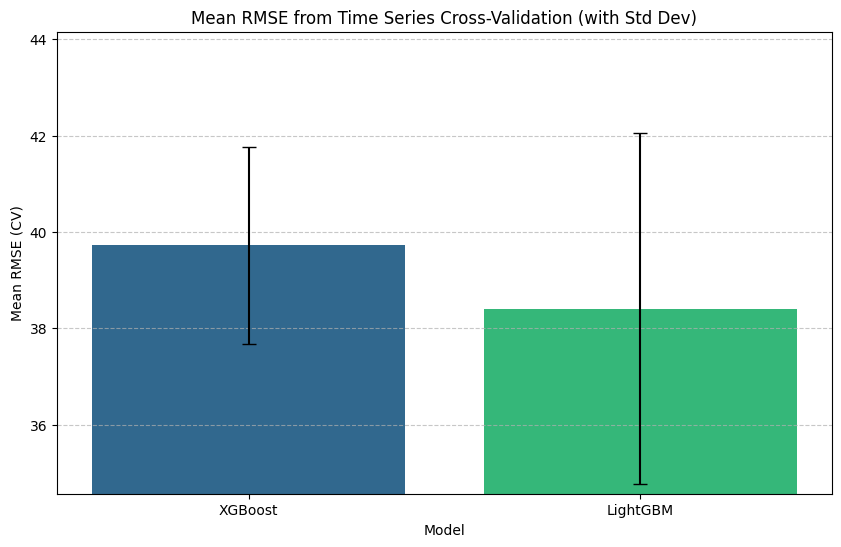

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns # Keep seaborn imported for potential styling options or other uses
import numpy as np

plt.figure(figsize=(10, 6))

# Get the data for plotting directly from the cv_results_df
models = cv_results_df['Model']
mean_rmse = cv_results_df['Mean RMSE (CV)']
std_rmse = cv_results_df['Std RMSE (CV)']

# Create the x-axis positions for the bars
x_pos = np.arange(len(models))

# Create the bar plot using matplotlib.pyplot.bar
plt.bar(x_pos, mean_rmse, yerr=std_rmse, capsize=5, color=sns.color_palette('viridis', len(models)))

# Set x-axis labels
plt.xticks(x_pos, models)

# Add labels and title
plt.title('Mean RMSE from Time Series Cross-Validation (with Std Dev)')
plt.xlabel('Model')
plt.ylabel('Mean RMSE (CV)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(bottom=mean_rmse.min() * 0.9) # Adjust y-axis limit for better visualization

plt.show()

## Save Tuned Models

This section saves the trained and tuned XGBoost and LightGBM models to disk using `joblib.dump`. This allows for easy loading and deployment of the models without needing to retrain them, ensuring that the best performing models from this notebook are readily available for future use (e.g., inference, further analysis).

In [32]:
import joblib
import os

# Define the paths for saving the models
output_model_path_xgb = os.path.join(project_base_dir, 'models', 'xgb_model.pkl')
output_model_path_lgb = os.path.join(project_base_dir, 'models', 'lgb_model.pkl')

# Create the models directory if it doesn't exist
os.makedirs(os.path.dirname(output_model_path_xgb), exist_ok=True)

# Save the tuned XGBoost model
joblib.dump(model_xgb_tuned, output_model_path_xgb)
print(f"Tuned XGBoost model saved to {output_model_path_xgb}")

# Save the tuned LightGBM model
joblib.dump(model_lgb_tuned, output_model_path_lgb)
print(f"Tuned LightGBM model saved to {output_model_path_lgb}")

Tuned XGBoost model saved to /content/drive/MyDrive/matatu_ml/models/xgb_model.pkl
Tuned LightGBM model saved to /content/drive/MyDrive/matatu_ml/models/lgb_model.pkl


## Robustness Test: Gaussian Noise Injection

This section evaluates the robustness of the tuned XGBoost and LightGBM models to noise in the input features. Gaussian noise (with a standard deviation of 10% of the feature's standard deviation) will be injected into the `numerical_features` of the `X_processed` dataset. The models will then be retrained and re-evaluated on this noisy data, and the RMSE degradation will be assessed against the original model performance. A degradation of less than 15% will be considered acceptable, indicating good robustness.

In [26]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import lightgbm as lgb
import os
import json

print("Starting robustness test with Gaussian noise injection...")

# 1. Create a noisy version of X_processed
X_processed_noisy = X_processed.copy()

# Identify numerical features (assuming these are the 'proxy features' for noise)
# Re-using the 'numerical_features' list from earlier in the notebook
# numerical_features defined in cell Td9M2zqLNmWU

print(f"Injecting noise into the following numerical features: {numerical_features}")

for feature in numerical_features:
    # Calculate 10% of the feature's standard deviation
    feature_std = X_processed_noisy[feature].std()
    noise_std = 0.10 * feature_std # 10% Gaussian noise

    # Generate Gaussian noise
    noise = np.random.normal(0, noise_std, size=X_processed_noisy.shape[0])

    # Add noise to the feature
    X_processed_noisy[feature] = X_processed_noisy[feature] + noise

print("Noise injected into X_processed_noisy.")

# 2. Re-split the noisy data into training and testing sets
# Using the same random_state as the original split for consistency
X_train_noisy, X_test_noisy, y_train_noisy, y_test_noisy = train_test_split(X_processed_noisy, y, test_size=0.2, random_state=42)

print(f"Noisy data split. X_train_noisy shape: {X_train_noisy.shape}, X_test_noisy shape: {X_test_noisy.shape}")

# 3. Re-evaluate Tuned XGBoost Model
print("\nRe-evaluating Tuned XGBoost Model with noisy data...")

# Load best parameters for XGBoost
output_file_path_xgb_params = os.path.join(project_base_dir, 'models', 'xgb_best_params.json')
with open(output_file_path_xgb_params, 'r') as f:
    best_params_xgb_noisy = json.load(f)

model_xgb_noisy = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    **best_params_xgb_noisy
)
model_xgb_noisy.fit(X_train_noisy, y_train_noisy)
y_pred_xgb_noisy = model_xgb_noisy.predict(X_test_noisy)
rmse_xgb_noisy = np.sqrt(mean_squared_error(y_test_noisy, y_pred_xgb_noisy))

print(f"XGBoost RMSE with noisy features: {rmse_xgb_noisy:.2f}")

# 4. Re-evaluate Tuned LightGBM Model
print("\nRe-evaluating Tuned LightGBM Model with noisy data...")

# Load best parameters for LightGBM
output_file_path_lgb_params = os.path.join(project_base_dir, 'models', 'lgb_best_params.json')
with open(output_file_path_lgb_params, 'r') as f:
    best_params_lgb_noisy = json.load(f)

model_lgb_noisy = lgb.LGBMRegressor(
    objective='regression',
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    **best_params_lgb_noisy
)
model_lgb_noisy.fit(X_train_noisy, y_train_noisy)
y_pred_lgb_noisy = model_lgb_noisy.predict(X_test_noisy)
rmse_lgb_noisy = np.sqrt(mean_squared_error(y_test_noisy, y_pred_lgb_noisy))

print(f"LightGBM RMSE with noisy features: {rmse_lgb_noisy:.2f}")

# 5. Calculate RMSE Degradation
# Using original RMSE values from previously stored variables (rmse_tuned_xgb, rmse_tuned_lgb)

degradation_xgb = ((rmse_xgb_noisy - rmse_tuned_xgb) / rmse_tuned_xgb) * 100
degradation_lgb = ((rmse_lgb_noisy - rmse_tuned_lgb) / rmse_tuned_lgb) * 100

print(f"\nRMSE Degradation for XGBoost: {degradation_xgb:.2f}%")
print(f"RMSE Degradation for LightGBM: {degradation_lgb:.2f}%")

# Check degradation condition
threshold = 15.0
print(f"\nDegradation Check (< {threshold}%):")
print(f"  XGBoost degradation < {threshold}%: {degradation_xgb < threshold}")
print(f"  LightGBM degradation < {threshold}%: {degradation_lgb < threshold}")

# 6. Save results to CSV
noise_test_results = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM'],
    'Original RMSE': [rmse_tuned_xgb, rmse_tuned_lgb],
    'Noisy RMSE': [rmse_xgb_noisy, rmse_lgb_noisy],
    'RMSE Degradation (%)': [degradation_xgb, degradation_lgb],
    f'Degradation < {threshold}%': [degradation_xgb < threshold, degradation_lgb < threshold]
})

output_file_path_noise_test = os.path.join(project_base_dir, 'models', 'noise_test.csv')
os.makedirs(os.path.dirname(output_file_path_noise_test), exist_ok=True)
noise_test_results.to_csv(output_file_path_noise_test, index=False)

print(f"\nRobustness test results saved to {output_file_path_noise_test}")
display(noise_test_results)

Starting robustness test with Gaussian noise injection...
Injecting noise into the following numerical features: ['temperature_c', 'rainfall_mm', 'wind_speed', 'Super (PMS)', 'Diesel (AGO)', 'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h', 'rainfall_x_hour', 'traffic_index']
Noise injected into X_processed_noisy.
Noisy data split. X_train_noisy shape: (492, 18), X_test_noisy shape: (124, 18)

Re-evaluating Tuned XGBoost Model with noisy data...
XGBoost RMSE with noisy features: 34.77

Re-evaluating Tuned LightGBM Model with noisy data...
LightGBM RMSE with noisy features: 35.17

RMSE Degradation for XGBoost: -0.99%
RMSE Degradation for LightGBM: -2.17%

Degradation Check (< 15.0%):
  XGBoost degradation < 15.0%: True
  LightGBM degradation < 15.0%: True

Robustness test results saved to /content/drive/MyDrive/matatu_ml/models/noise_test.csv


,Model,Original RMSE,Noisy RMSE,RMSE Degradation (%),Degradation < 15.0%
0,XGBoost,35.120623,34.772899,-0.990084,True
1,LightGBM,35.952265,35.172557,-2.168731,True
